In [63]:
import os
import io
import gzip
import json
import warnings
import logging

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import matplotlib.patches as mpatches

from dotenv import load_dotenv
from google.cloud import storage

warnings.filterwarnings("ignore")
logging.getLogger("transformers").setLevel(logging.ERROR)

In [2]:
# load combined data

df = pd.read_csv("/Users/johnhutchens/Desktop/Practicum/Data/ESM2_ft_all_pfam_sp.csv.gz")

In [44]:
df.head()

,model,domain_id,uniprot_id,in_pfam_train,n,rho_base,p_base,rho_ft,p_ft,delta_rho,pfam
0,PF00010,Q7Z6G8_PF00536_812,Q7Z6G8,False,1143,0.257597,8.820103e-19,0.787307,6.918559e-242,0.529710,PF00536
1,PF11722,Q9NUP7_PF11722_18,Q9NUP7,True,439,0.026799,5.754848e-01,0.539265,1.734913e-34,0.512467,PF11722
2,PF00010,Q8WU90_PF18044_104,Q8WU90,False,397,0.166906,8.422100e-04,0.626052,1.362520e-44,0.459146,PF18044
3,PF00569,Q9Y4J8_PF00569_235,Q9Y4J8,True,1119,0.188510,2.071464e-10,0.629437,1.623944e-124,0.440927,PF00569
4,PF02209,P09327_PF02209_793,P09327,True,632,0.186976,2.212267e-06,0.618647,5.136239e-68,0.431671,PF02209


In [9]:
# counting domains in pfams

pfam_counts = (
    df[df['model']=='all_pfams']['pfam']
    .value_counts()
    .reset_index()
)

pfam_counts.columns = ['pfam', 'count']

In [17]:
model_valid = list(pfam_counts[pfam_counts['count'] > 4]['pfam'])
# model_valid.append('all_pfams')

In [18]:
df_valid = df[df['pfam'].isin(model_valid)]

In [45]:
df_valid.head()

,model,domain_id,uniprot_id,in_pfam_train,n,rho_base,p_base,rho_ft,p_ft,delta_rho,pfam
0,PF00010,Q7Z6G8_PF00536_812,Q7Z6G8,False,1143,0.257597,8.820103e-19,0.787307,6.918559e-242,0.529710,PF00536
8,PF06467,Q9UJ78_PF06467_334,Q9UJ78,True,678,0.186368,1.025662e-06,0.587158,4.585924e-64,0.400790,PF06467
11,PF00010,P22681_PF00627_854,P22681,False,850,0.235321,3.693812e-12,0.618500,7.292570e-91,0.383179,PF00627
18,PF00010,Q15365_PF00013_278,Q15365,False,1360,0.370119,2.091066e-45,0.711415,2.862550e-210,0.341296,PF00013
20,PF00010,Q9UJ78_PF06467_334,Q9UJ78,False,678,0.186368,1.025662e-06,0.517991,8.172506e-48,0.331623,PF06467


# Extreme cases

In [65]:
load_dotenv()
cred_path = os.getenv('GOOGLE_APPLICATION_CREDENTIALS')

os.environ['GOOGLE_APPLICATION_CREDENTIALS'] = cred_path

GCS_PROJECT = "plm-study-484223"
GCS_BUCKET = "domainome-data"

client = storage.Client(project=GCS_PROJECT)
bucket = client.bucket(GCS_BUCKET)


## Bad PFAM models
### PF00046

In [85]:
blob_path = 'ESM2/ft_per_pfam/global_finetune/PF00046/sweep_curves.json'
blob = bucket.blob(blob_path)
data = blob.download_as_text()

train_PF00046 = json.loads(data)
blob_path = 'ESM2/ft_per_pfam/global_finetune/PF00046/metadata.json'
blob = bucket.blob(blob_path)
data = blob.download_as_text()

meta_PF00046 = json.loads(data)
train_dict = train_PF00046
best_config = meta_PF00046["best_config"]

list_best_train_PF00046 = [
    d for d in train_dict
    if d.get("lr") == best_config['lr']
    and d.get("lora_r") == best_config['lora_r']
]

print(f"Number of best lora configs: {len(list_best_train_PF00046)}")
best_train_PF00046 = list_best_train_PF00046[0]
# best_train_PF00046
doms = best_train_PF00046['train_sampled_domains']
PF00046_train_doms = pd.DataFrame({'domain_id': sum(doms, [])})
PF00046_train_doms = PF00046_train_doms.value_counts().reset_index(name='count')

Number of best lora configs: 1


In [86]:
PF00046_train_doms

,domain_id,count
0,O75360_PF00046_71,5
1,P35548_PF00046_144,4
2,P26367_PF00046_213,4
3,O95076_PF00046_155,4
4,Q8NFW5_PF00046_73,3
5,P32243_PF00046_40,3
6,O15266_PF00046_119,3
7,P20265_PF00046_356,3
8,O95475_PF00046_134,3
9,P23759_PF00046_219,2


### PF00536

In [88]:
blob_path = 'ESM2/ft_per_pfam/global_finetune/PF00536/sweep_curves.json'
blob = bucket.blob(blob_path)
data = blob.download_as_text()
train_PF00536 = json.loads(data)

blob_path = 'ESM2/ft_per_pfam/global_finetune/PF00536/metadata.json'
blob = bucket.blob(blob_path)
data = blob.download_as_text()
meta_PF00536 = json.loads(data)

train_dict = train_PF00536
best_config = meta_PF00536["best_config"]

list_best_train_PF00536 = [
    d for d in train_dict
    if d.get("lr") == best_config['lr']
    and d.get("lora_r") == best_config['lora_r']
]

print(f"Number of best lora configs: {len(list_best_train_PF00536)}")
best_train_PF00536 = list_best_train_PF00536[0]

doms = best_train_PF00536['train_sampled_domains']
PF00536_train_doms = pd.DataFrame({'domain_id': sum(doms, [])})
PF00536_train_doms = PF00536_train_doms.value_counts().reset_index(name='count')

Number of best lora configs: 1


In [89]:
PF00536_train_doms

,domain_id,count
0,Q9NYL2_PF00536_330,24
1,O94885_PF00536_630,20
2,O94830_PF00536_389,16
3,Q8WXI2_PF00536_9,16
4,Q68DC2_PF00536_774,12
5,Q7Z6G8_PF00536_812,12


## Good PFAM models
### PF00505

In [90]:
blob_path = 'ESM2/ft_per_pfam/global_finetune/PF00505/sweep_curves.json'
blob = bucket.blob(blob_path)
data = blob.download_as_text()
train_PF00505 = json.loads(data)

blob_path = 'ESM2/ft_per_pfam/global_finetune/PF00505/metadata.json'
blob = bucket.blob(blob_path)
data = blob.download_as_text()
meta_PF00505 = json.loads(data)

train_dict = train_PF00505
best_config = meta_PF00505["best_config"]

list_best_train_PF00505 = [
    d for d in train_dict
    if d.get("lr") == best_config['lr']
    and d.get("lora_r") == best_config['lora_r']
]

print(f"Number of best lora configs: {len(list_best_train_PF00505)}")
best_train_PF00505 = list_best_train_PF00505[0]

doms = best_train_PF00505['train_sampled_domains']
PF00505_train_doms = pd.DataFrame({'domain_id': sum(doms, [])})
PF00505_train_doms = PF00505_train_doms.value_counts().reset_index(name='count')

Number of best lora configs: 1


In [91]:
PF00505_train_doms

,domain_id,count
0,P35712_PF00505_622,21
1,O94993_PF00505_338,19
2,P35711_PF00505_557,16
3,Q06945_PF00505_60,15
4,P35716_PF00505_50,15
5,Q86U86_PF00505_1383,15
6,P41225_PF00505_140,14
7,O15405_PF00505_256,13
8,Q9H6I2_PF00505_69,13
9,P17480_PF00505_408,12


### PF00013

In [92]:
blob_path = 'ESM2/ft_per_pfam/global_finetune/PF00013/sweep_curves.json'
blob = bucket.blob(blob_path)
data = blob.download_as_text()
train_PF00013 = json.loads(data)

blob_path = 'ESM2/ft_per_pfam/global_finetune/PF00013/metadata.json'
blob = bucket.blob(blob_path)
data = blob.download_as_text()
meta_PF00013 = json.loads(data)

train_dict = train_PF00013
best_config = meta_PF00013["best_config"]

list_best_train_PF00013 = [
    d for d in train_dict
    if d.get("lr") == best_config['lr']
    and d.get("lora_r") == best_config['lora_r']
]

print(f"Number of best lora configs: {len(list_best_train_PF00013)}")
best_train_PF00013 = list_best_train_PF00013[0]

doms = best_train_PF00013['train_sampled_domains']
PF00013_train_doms = pd.DataFrame({'domain_id': sum(doms, [])})
PF00013_train_doms = PF00013_train_doms.value_counts().reset_index(name='count')

Number of best lora configs: 1


In [93]:
PF00013_train_doms

,domain_id,count
0,Q86XN8_PF00013_273,13
1,Q06787_PF00013_217,12
2,Q5U5Q3_PF00013_325,11
3,Q96I24_PF00013_75,11
4,P61978_PF00013_385,8
5,Q96AE4_PF00013_98,8
6,Q15365_PF00013_278,7
7,Q92945_PF00013_142,5
8,Q96AE4_PF00013_184,5


# Boxplots

In [53]:
df_base = df_valid[df_valid['model'] == df_valid['pfam']]
df_ft_all = df_valid[df_valid['model'] == 'all_pfams']
df_ft_pfam = df_valid[df_valid['model'] == df_valid['pfam']]

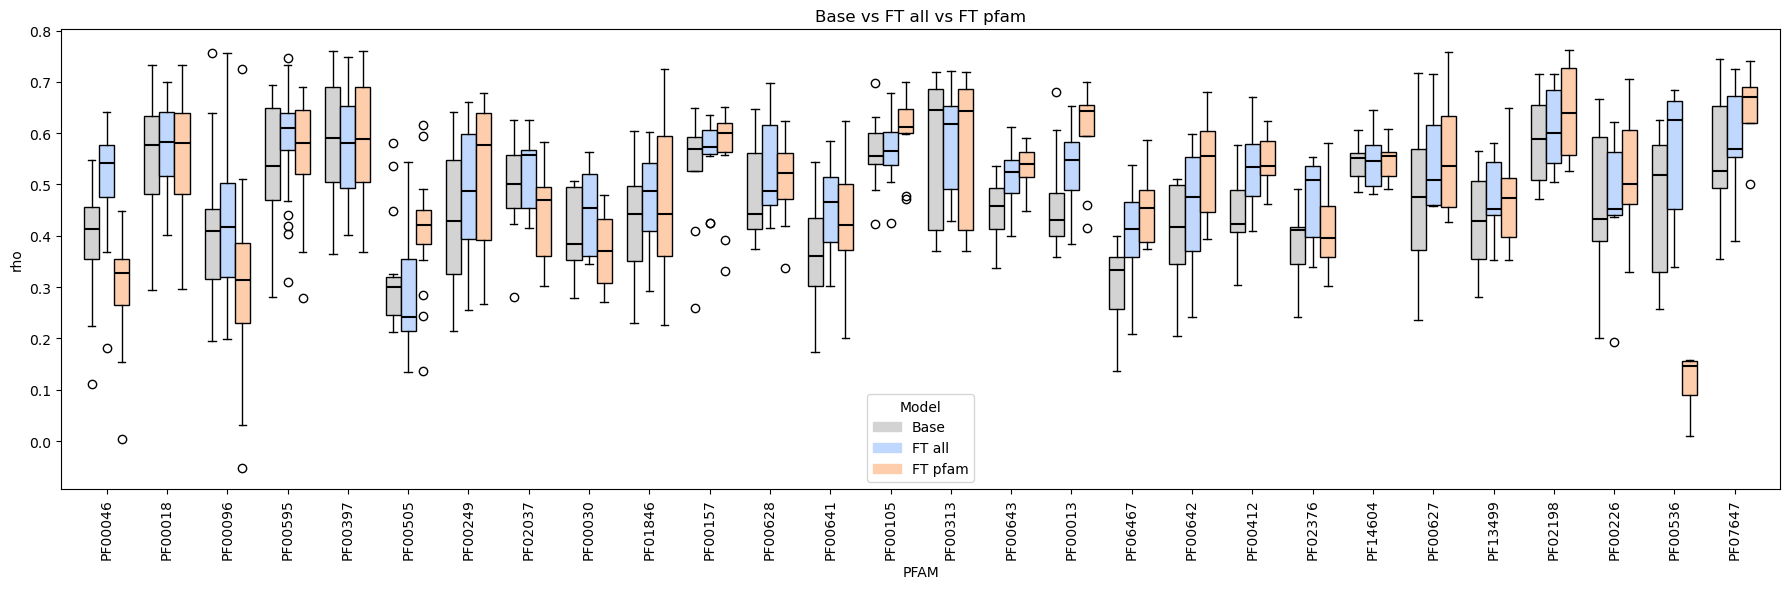

In [60]:
pfam_order = df_valid['pfam'].value_counts().index

x = np.arange(len(pfam_order))
width = 0.25

base_color = 'lightgray'
ft_all_color = "#c0d8fd"
ft_pfam_color = "#fecdac"

base_data = [df_base[df_base['pfam'] == p]['rho_base'] for p in pfam_order]

ft_all_data = [
    df_ft_all[df_ft_all['pfam'] == p]['rho_ft'] for p in pfam_order
]

ft_pfam_data = [
    df_ft_pfam[df_ft_pfam['pfam'] == p]['rho_ft'] for p in pfam_order
]

fig, ax = plt.subplots(figsize=(18, 6))

medianprops = dict(color='black', linewidth=1.5)

# base
ax.boxplot(
    base_data,
    positions=x - width,
    widths=width,
    patch_artist=True,
    boxprops=dict(facecolor=base_color),
    medianprops=medianprops
)

# ft all
ax.boxplot(
    ft_all_data,
    positions=x,
    widths=width,
    patch_artist=True,
    boxprops=dict(facecolor=ft_all_color),
    medianprops=medianprops
)

# ft pfam
ax.boxplot(
    ft_pfam_data,
    positions=x + width,
    widths=width,
    patch_artist=True,
    boxprops=dict(facecolor=ft_pfam_color),
    medianprops=medianprops
)


ax.set_xticks(x)
ax.set_xticklabels(pfam_order, rotation=90)

ax.set_xlabel("PFAM")
ax.set_ylabel("rho")
ax.set_title("Base vs FT all vs FT pfam")

base_patch = mpatches.Patch(color=base_color, label='Base')
ft_all_patch = mpatches.Patch(color=ft_all_color, label='FT all')
ft_pfam_patch = mpatches.Patch(color=ft_pfam_color, label='FT pfam')

ax.legend(handles=[base_patch, ft_all_patch, ft_pfam_patch], title="Model")

plt.tight_layout()
plt.show()



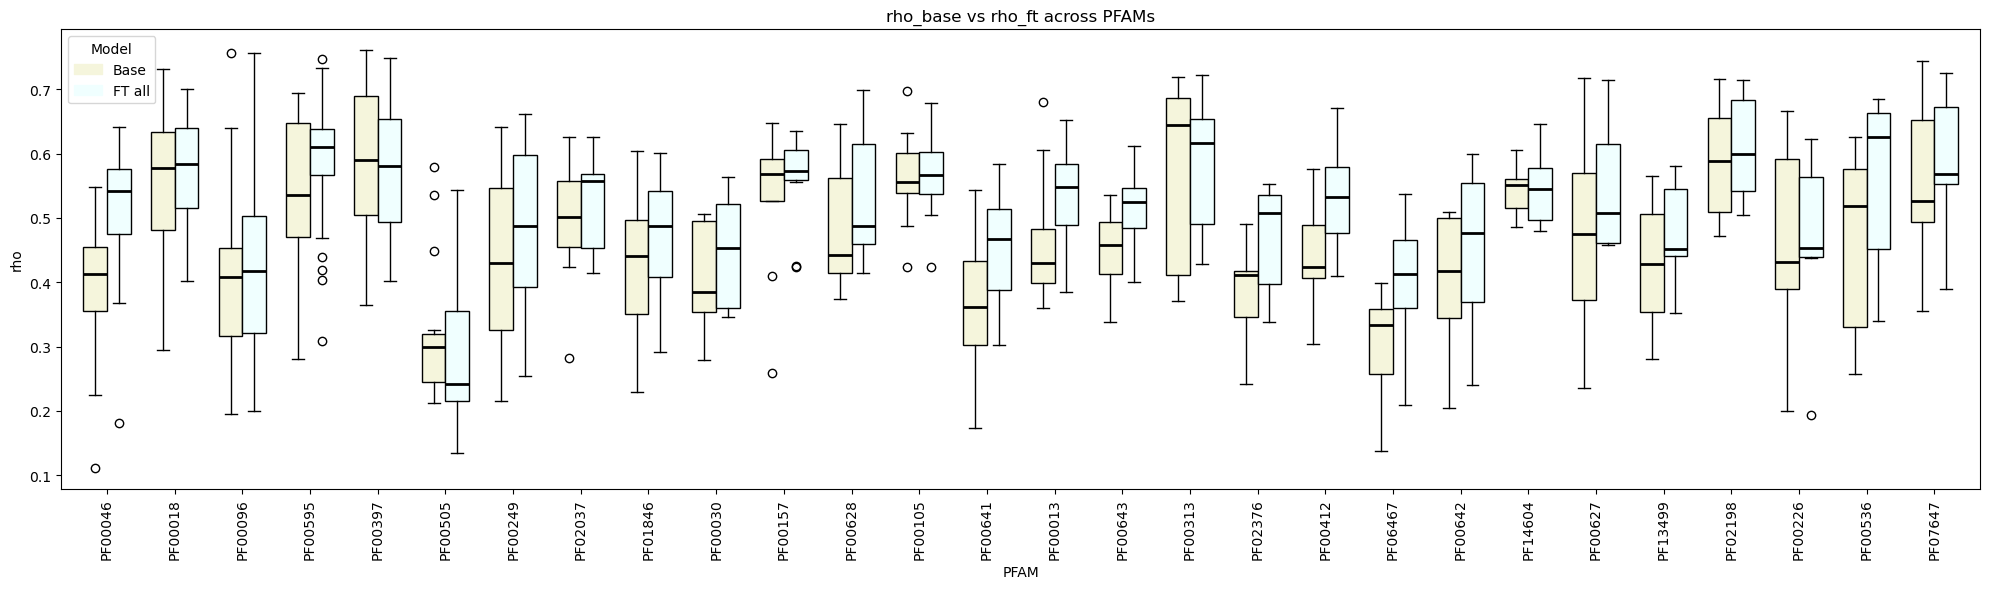

In [43]:
df_all = df_valid[df_valid['model'] == 'all_pfams']

pfam_order = df_all['pfam'].value_counts().index

# numeric x positions
x = np.arange(len(pfam_order))
width = 0.35
medianprops = dict(color='black', linewidth=2)

fig, ax = plt.subplots(figsize=(20, 6))

# data aligned to pfam order
base_data = [df_all[df_all['pfam'] == p]['rho_base'] for p in pfam_order]
ft_data   = [df_all[df_all['pfam'] == p]['rho_ft'] for p in pfam_order]

# boxplots with offsets
ax.boxplot(base_data, 
           positions=x - width/2, 
           widths=width, 
           patch_artist=True,
           boxprops=dict(facecolor='beige'),
           medianprops=medianprops)

ax.boxplot(ft_data,
           positions=x + width/2, 
           widths=width, 
           patch_artist=True,
           boxprops=dict(facecolor='azure'),
           medianprops=medianprops)

# labels
ax.set_xticks(x)
ax.set_xticklabels(pfam_order, rotation=90)

ax.set_xlabel("PFAM")
ax.set_ylabel("rho")
ax.set_title("rho_base vs rho_ft across PFAMs")

base_patch = mpatches.Patch(color='beige', label='Base')
ft_patch   = mpatches.Patch(color='azure', label='FT all')

ax.legend(handles=[base_patch, ft_patch], title="Model")

plt.tight_layout()
plt.show()

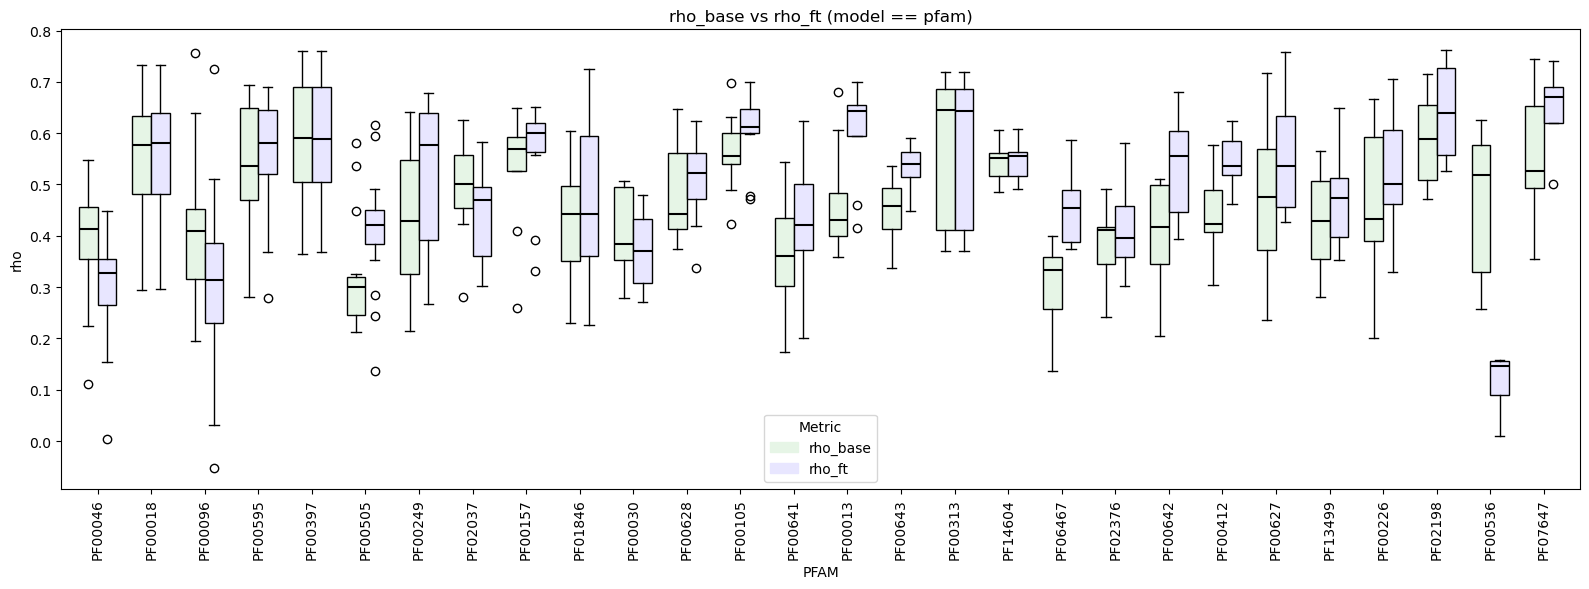

In [52]:

df_plot = df_valid[df_valid['model'] == df_valid['pfam']]

pfam_order = df_plot['pfam'].value_counts().index

x = np.arange(len(pfam_order))
width = 0.35

fig, ax = plt.subplots(figsize=(16, 6))

# align data to pfam order
base_data = [df_plot[df_plot['pfam'] == p]['rho_base'] for p in pfam_order]
ft_data   = [df_plot[df_plot['pfam'] == p]['rho_ft'] for p in pfam_order]

medianprops = dict(color='black', linewidth=1.5)

# rho_base (left)
ax.boxplot(
    base_data,
    positions=x - width/2,
    widths=width,
    patch_artist=True,
    boxprops=dict(facecolor='#e6f5e6'),
    medianprops=medianprops
)

# rho_ft (right)
ax.boxplot(
    ft_data,
    positions=x + width/2,
    widths=width,
    patch_artist=True,
    boxprops=dict(facecolor="#e8e6ff"),
    medianprops=medianprops
)

# axis labels
ax.set_xticks(x)
ax.set_xticklabels(pfam_order, rotation=90)

ax.set_xlabel("PFAM")
ax.set_ylabel("rho")
ax.set_title("rho_base vs rho_ft (model == pfam)")

# legend
import matplotlib.patches as mpatches

base_patch = mpatches.Patch(color='#e6f5e6', label='rho_base')
ft_patch   = mpatches.Patch(color="#e8e6ff", label='rho_ft')

ax.legend(handles=[base_patch, ft_patch], title="Metric")

plt.tight_layout()
plt.show()

In [46]:
df_plot = df_valid[
    (df_valid['model'] == df_valid['pfam'])
]

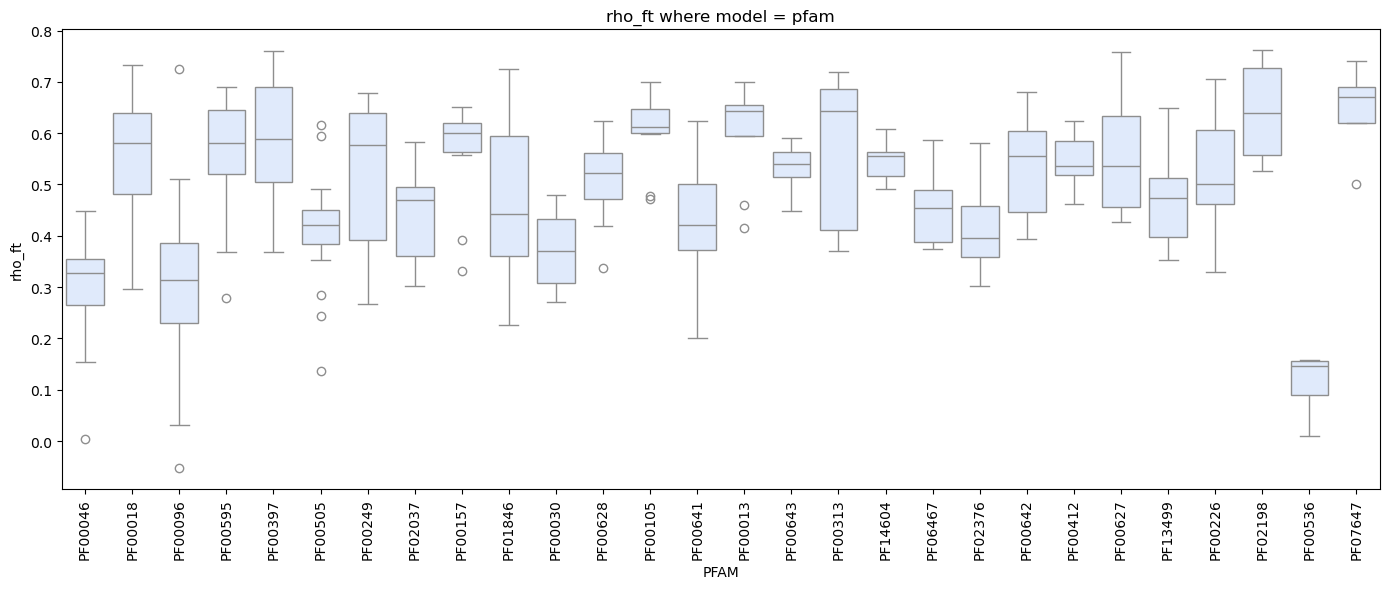

In [48]:
pfam_order = df_plot['pfam'].value_counts().index

plt.figure(figsize=(14, 6))

sns.boxplot(
    data=df_plot,
    x='pfam',
    y='rho_ft',
    order=pfam_order,
    color='#dbe9ff'
)

plt.xticks(rotation=90)
plt.xlabel("PFAM")
plt.ylabel("rho_ft")
plt.title("rho_ft where model = pfam")

plt.tight_layout()
plt.show()

# Make combined csv

In [ ]:
# load pfam data
datafile = "/Users/johnhutchens/Desktop/Practicum/Data/ESM2_ESM2_ft_combined_sp_df.csv.gz"

with gzip.open(datafile, "rt") as f:
    df = pd.read_csv(f)

In [ ]:
# load all domain data
datafile = "/Users/johnhutchens/Desktop/Practicum/Data/ESM2_ft_all_doms_run2_global_finetune_ESM2_ft_all_sp_df.csv.gz"

with gzip.open(datafile, "rt") as f:
    df_all = pd.read_csv(f)

In [13]:
df_all.head()

,domain_id,uniprot_id,n,rho_base,p_base,rho_ft,p_ft,delta_rho,pfam
0,Q9Y6N9_PF00595_207,Q9Y6N9,1255,0.378841,4.165029e-44,0.626113,1.456364e-137,0.247273,PF00595
1,P20936_PF00018_281,P20936,1158,0.422455,2.486852e-51,0.666934,6.875281e-150,0.244478,PF00018
2,Q86VP1_PF18112_729,Q86VP1,494,0.299746,1.029321e-11,0.531721,2.119634e-37,0.231975,PF18112
3,P22681_PF00627_854,P22681,850,0.235321,3.693812e-12,0.457588,3.250431e-45,0.222268,PF00627
4,Q9P0J7_PF05605_76,Q9P0J7,1093,0.303563,9.848891e-25,0.520061,9.076428e-77,0.216498,PF05605


In [ ]:
# counting domains in pfams

pfam_counts = (
    df_all['pfam']
    .value_counts()
    .reset_index()
)

pfam_counts.columns = ['pfam', 'count']

In [ ]:
# list of pfams with at least 5 domains
pfam_g4 = pfam_counts[pfam_counts['count']>4]['pfam']

In [21]:
df_comb = pd.concat([df, df_all])

In [26]:
df_comb.head()

,model,domain_id,uniprot_id,in_pfam_train,n,rho_base,p_base,rho_ft,p_ft,delta_rho,pfam
0,PF00010,Q7Z6G8_PF00536_812,Q7Z6G8,False,1143,0.257597,8.820103e-19,0.787307,6.918559e-242,0.529710,PF00536
1,PF11722,Q9NUP7_PF11722_18,Q9NUP7,True,439,0.026799,5.754848e-01,0.539265,1.734913e-34,0.512467,PF11722
2,PF00010,Q8WU90_PF18044_104,Q8WU90,False,397,0.166906,8.422100e-04,0.626052,1.362520e-44,0.459146,PF18044
3,PF00569,Q9Y4J8_PF00569_235,Q9Y4J8,True,1119,0.188510,2.071464e-10,0.629437,1.623944e-124,0.440927,PF00569
4,PF02209,P09327_PF02209_793,P09327,True,632,0.186976,2.212267e-06,0.618647,5.136239e-68,0.431671,PF02209


In [24]:
df_comb['model'] = df_comb['model'].fillna('all_pfams')

In [27]:
df_comb.to_csv("/Users/johnhutchens/Desktop/Practicum/Data/ESM2_ft_all_pfam_sp.csv.gz", index=False, compression='gzip')

# Sanity checks

In [12]:
df_all[df_all['domain_id']=='Q9NUP7_PF11722_18']

,domain_id,uniprot_id,n,rho_base,p_base,rho_ft,p_ft,delta_rho,pfam
247,Q9NUP7_PF11722_18,Q9NUP7,439,0.026799,0.575485,0.064433,0.177798,0.037634,PF11722


In [11]:
df[df['domain_id']=='Q9NUP7_PF11722_18']

,model,domain_id,uniprot_id,in_pfam_train,n,rho_base,p_base,rho_ft,p_ft,delta_rho,pfam
1,PF11722,Q9NUP7_PF11722_18,Q9NUP7,True,439,0.026799,0.575485,0.539265,1.734913e-34,0.512467,PF11722
27,PF02008,Q9NUP7_PF11722_18,Q9NUP7,False,439,0.026799,0.575485,0.348148,5.916150e-14,0.321349,PF11722
203,PF01246,Q9NUP7_PF11722_18,Q9NUP7,False,439,0.026799,0.575485,0.242614,2.662307e-07,0.215815,PF11722
241,PF18044,Q9NUP7_PF11722_18,Q9NUP7,False,439,0.026799,0.575485,0.233943,7.173038e-07,0.207144,PF11722
439,PF06220,Q9NUP7_PF11722_18,Q9NUP7,False,439,0.026799,0.575485,0.201727,2.058449e-05,0.174928,PF11722
...,...,...,...,...,...,...,...,...,...,...,...
59556,PF00787,Q9NUP7_PF11722_18,Q9NUP7,False,439,0.026799,0.575485,-0.006317,8.950084e-01,-0.033115,PF11722
60700,PF09329,Q9NUP7_PF11722_18,Q9NUP7,False,439,0.026799,0.575485,-0.022249,6.420053e-01,-0.049048,PF11722
60866,PF18366,Q9NUP7_PF11722_18,Q9NUP7,False,439,0.026799,0.575485,-0.025644,5.920536e-01,-0.052443,PF11722
61522,PF07525,Q9NUP7_PF11722_18,Q9NUP7,False,439,0.026799,0.575485,-0.044627,3.509041e-01,-0.071426,PF11722


In [9]:
df['in_pfam_train'].unique()

array([False,  True])

In [5]:
df['model'].unique()

array(['PF00010', 'PF11722', 'PF00569', 'PF02209', 'PF02187', 'PF01246',
       'PF06467', 'PF10650', 'PF02008', 'PF18044', 'PF01429', 'PF02295',
       'PF00787', 'PF18112', 'PF09329', 'PF02207', 'PF00013', 'PF00412',
       'PF00533', 'PF05225', 'PF00567', 'PF00536', 'PF05715', 'PF13639',
       'PF02185', 'PF00096', 'PF00642', 'PF00240', 'PF00831', 'PF02037',
       'PF00320', 'PF12171', 'PF00619', 'PF00595', 'PF00458', 'PF06220',
       'PF11793', 'PF16557', 'PF00249', 'PF07647', 'PF00035', 'PF00280',
       'PF05605', 'PF08313', 'PF02270', 'PF17035', 'PF00627', 'PF00538',
       'PF01846', 'PF00778', 'PF01480', 'PF08073', 'PF02172', 'PF02376',
       'PF07525', 'PF01335', 'PF02845', 'PF14369', 'PF00505', 'PF01381',
       'PF13891', 'PF10264', 'PF00612', 'PF00130', 'PF03638', 'PF00046',
       'PF04855', 'PF02359', 'PF11515', 'PF18410', 'PF18366', 'PF00643',
       'PF02198', 'PF16558', 'PF02017', 'PF00385', 'PF02179', 'PF18694',
       'PF02196', 'PF00789', 'PF04433', 'PF12678', 